# Glamsterdam Aggregate Equilibrium Model

This notebook replaces the 500-block block-shape diagnostic as the main way to
reason about the **Glamsterdam equilibrium base fee**.

The object here is aggregate, not transaction-level:

1. Build a long historical anchor for current-rule gas demand.
2. Split current gas into state, data, and execution.
3. Apply counterfactual Glamsterdam metering multipliers.
4. Solve for the single EIP-1559 base fee that makes the EIP-8037 bottleneck hit
   the target.

For Glamsterdam, the fee market is still one shared EIP-1559 market. The gas-use
input is:

$$
G_{\text{Glamsterdam}}
=
\max\left(
  m_{\text{execution}} q_{\text{execution}}
  + m_{\text{data}} q_{\text{data}},
  m_{\text{state}} q_{\text{state}}
\right)
$$

where $q_r$ is physical demand measured in historical/current-rule gas units and
$m_r$ is the counterfactual metering multiplier for resource $r$.


## Relation To Maria's Models

Maria's empirical report uses a capacity-constrained demand model:

$$
G^{\text{total}}(p) = A p^{-\epsilon_{\text{agg}}}
$$

$$
\alpha_s(mp)
= \frac{1}{1 + \kappa (mp)^{\eta_{\text{state}}}}
$$

So yes, that model already contains a repricing multiplier $m$ in the state-share
term. Maria's follow-up then sweeps $m$ when comparing EIP-8037 aggregation
functions.

Here we generalize the same idea to three historical components:

$$
\text{historical demand} = \text{execution} + \text{data} + \text{state}
$$

and then sweep:

- $m_{\text{state}}$: current-rule state-creation gas to EIP-8037 state gas;
- $m_{\text{data}}$: current-rule calldata/data gas to Glamsterdam EIP-7976 and
  EIP-7981 data pressure;
- $m_{\text{execution}}$: usually kept near 1.


## Setup


In [1]:
from itertools import product
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from demand import Anchor, DemandParams, FeeDimension, WorldSpec, solve_equilibrium, implied_anchor_elasticities

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

START_DATE = pd.Timestamp("2025-01-01")
END_DATE_EXCLUSIVE = pd.Timestamp("2026-06-01")
DATE_LABEL = "2025-01-01_2026-06-01"

# If a fully refreshed long panel exists later, this notebook will use it.
LONG_PANEL_CSV = DATA_DIR / f"glamsterdam_equilibrium_daily_panel_{DATE_LABEL}.csv"
OUT_PANEL_CSV = DATA_DIR / f"glamsterdam_aggregate_equilibrium_panel_{DATE_LABEL}.csv"
OUT_ANCHOR_CSV = DATA_DIR / f"glamsterdam_aggregate_equilibrium_anchors_{DATE_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"glamsterdam_aggregate_equilibrium_results_{DATE_LABEL}.csv"

PANEL_2025_CSV = DATA_DIR / "gas_limit_data_share_daily_2025-01-01_2026-01-05.csv"
PANEL_2026_CSVS = [
    DATA_DIR / "daily_accounting_panel_2026-01-05_2026-02-01.csv",
    DATA_DIR / "daily_accounting_panel_calibrated_no_bal_2026-02-01_2026-06-01.csv",
]
PANEL_2026_CURRENT_DATA_CSVS = [
    DATA_DIR / "daily_current_data_gas_xatu_2026-01-05_2026-02-01.csv",
    DATA_DIR / "daily_current_data_gas_xatu_2026-02-01_2026-06-01.csv",
]
PILOT_DECOMP_CSV = DATA_DIR / "g0_reference_decomposition_24120001_24120500.csv"

GWEI = 1e9


## Build The Historical Anchor Panel

The central anchor is a daily panel. Each row is one day, with gas quantities as
daily totals.

For 2025, we use the gas-limit/data-share panel because it already computes a
current-rule calldata/data gas proxy that includes EIP-7623 when active.

For 2026, we use the same transaction-level current-rule data-gas formula from
Xatu, split into the Jan bridge and the Feb-May extension:

```text
data/daily_current_data_gas_xatu_2026-01-05_2026-02-01.csv
data/daily_current_data_gas_xatu_2026-02-01_2026-06-01.csv
```

The 2026 state proxy is kept consistent with the aggregate historical anchor:
positive CBT net inventory deltas for accounts, storage bytes, and code bytes,
priced at current-rule costs. This keeps the anchor definition stable across the
2025 and 2026 segments.


In [2]:
def normalize_2025_panel(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    out = pd.DataFrame({
        "date": df["date"],
        "block_count": df["block_count"].astype(float),
        "min_block": df["min_block"].astype(int),
        "max_block": df["max_block"].astype(int),
        "gas_used_current": df["block_gas_used"].astype(float),
        "mean_gas_limit": df["mean_gas_limit"].astype(float),
        "median_gas_limit": df["median_gas_limit"].astype(float),
        "mean_base_fee_per_gas": df["mean_base_fee_per_gas"].astype(float),
        "median_base_fee_per_gas": df["median_base_fee_per_gas"].astype(float),
        "gas_weighted_base_fee_per_gas": df["gas_weighted_base_fee_per_gas"].astype(float),
        "state_gas_current": df["current_state_inventory_delta_gas_proxy"].astype(float),
        "data_gas_current": df["data_gas_current"].astype(float),
        "standard_calldata_gas": df["standard_calldata_gas"].astype(float),
        "data_source": "current_rule_xatu_eip7623_proxy",
        "state_source": "cbt_state_inventory_delta_proxy",
        "panel_source": path.name,
    })
    out["execution_gas_current_raw"] = (
        out["gas_used_current"] - out["state_gas_current"] - out["data_gas_current"]
    )
    out["execution_gas_current"] = out["execution_gas_current_raw"].clip(lower=0)
    return out


def read_existing_csvs(paths: list[Path]) -> pd.DataFrame:
    frames = []
    missing = []
    for path in paths:
        if path.exists():
            frame = pd.read_csv(path)
            frame["date"] = pd.to_datetime(frame["date"])
            frame["source_file"] = path.name
            frames.append(frame)
        else:
            missing.append(path)
    if missing:
        raise FileNotFoundError("Missing required panel files: " + ", ".join(str(p) for p in missing))
    return pd.concat(frames, ignore_index=True, sort=False).sort_values("date").reset_index(drop=True)


def load_exact_2026_current_data(paths: list[Path]) -> pd.DataFrame:
    exact = read_existing_csvs(paths)
    required = {"date", "data_gas_current", "standard_calldata_gas"}
    missing = required - set(exact.columns)
    if missing:
        raise ValueError(f"2026 current-data files are missing required columns: {sorted(missing)}")
    exact = exact[["date", "data_gas_current", "standard_calldata_gas", "source_file"]].copy()
    return exact.rename(columns={"source_file": "data_source_file"})


def current_state_proxy_from_net_inventory(df: pd.DataFrame) -> pd.Series:
    required = {"accounts_net_delta", "storage_bytes_net_delta", "contract_code_bytes_net_delta"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"2026 panel files are missing state proxy columns: {sorted(missing)}")
    return (
        df["accounts_net_delta"].clip(lower=0).astype(float) * 25_000
        + df["storage_bytes_net_delta"].clip(lower=0).astype(float) * (20_000 / 32)
        + df["contract_code_bytes_net_delta"].clip(lower=0).astype(float) * 200
    )


def normalize_2026_panel(paths: list[Path], current_data_paths: list[Path]) -> pd.DataFrame:
    exact_data = load_exact_2026_current_data(current_data_paths)
    df = read_existing_csvs(paths)
    df = df.drop(columns=[c for c in ["data_gas_current", "standard_calldata_gas"] if c in df.columns])
    df = df.merge(exact_data, on="date", how="left", validate="one_to_one")
    if df["data_gas_current"].isna().any():
        missing_dates = df.loc[df["data_gas_current"].isna(), "date"].dt.date.astype(str).tolist()
        raise ValueError(f"Exact 2026 current data gas missing for dates: {missing_dates[:5]}")

    out = pd.DataFrame({
        "date": df["date"],
        "block_count": df["block_count"].astype(float),
        "min_block": df["min_block"].astype(int),
        "max_block": df["max_block"].astype(int),
        "gas_used_current": df["current_gas_used"].astype(float),
        "mean_gas_limit": df["mean_gas_limit"].astype(float),
        "median_gas_limit": df.get("median_gas_limit", df["mean_gas_limit"]).astype(float),
        "mean_base_fee_per_gas": df["mean_base_fee_per_gas"].astype(float),
        "median_base_fee_per_gas": df["median_base_fee_per_gas"].astype(float),
        "gas_weighted_base_fee_per_gas": df["gas_weighted_base_fee_per_gas"].astype(float),
        "state_gas_current": current_state_proxy_from_net_inventory(df),
        "data_gas_current": df["data_gas_current"].astype(float),
        "standard_calldata_gas": df["standard_calldata_gas"].astype(float),
        "data_source": df["data_source_file"],
        "state_source": "cbt_state_inventory_delta_proxy",
        "panel_source": df["source_file"],
    })
    out["execution_gas_current_raw"] = (
        out["gas_used_current"] - out["state_gas_current"] - out["data_gas_current"]
    )
    out["execution_gas_current"] = out["execution_gas_current_raw"].clip(lower=0)
    return out


def load_or_build_panel() -> pd.DataFrame:
    if LONG_PANEL_CSV.exists():
        panel = pd.read_csv(LONG_PANEL_CSV)
        panel["date"] = pd.to_datetime(panel["date"])
        panel["panel_source"] = panel.get("panel_source", LONG_PANEL_CSV.name)
        return panel

    frames = [normalize_2025_panel(PANEL_2025_CSV)]
    frames.append(normalize_2026_panel(PANEL_2026_CSVS, PANEL_2026_CURRENT_DATA_CSVS))

    panel = pd.concat(frames, ignore_index=True, sort=False)
    panel = panel[(panel["date"] >= START_DATE) & (panel["date"] < END_DATE_EXCLUSIVE)].copy()
    panel = panel.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
    return panel

panel = load_or_build_panel()

for col in ["gas_used_current", "state_gas_current", "data_gas_current", "execution_gas_current"]:
    panel[f"{col}_per_block"] = panel[col] / panel["block_count"].replace(0, np.nan)

panel["state_share_current"] = panel["state_gas_current"] / panel["gas_used_current"].replace(0, np.nan)
panel["data_share_rest_current"] = panel["data_gas_current"] / (
    panel["data_gas_current"] + panel["execution_gas_current"]
).replace(0, np.nan)
panel["negative_execution_raw"] = panel["execution_gas_current_raw"] < 0

panel.to_csv(OUT_PANEL_CSV, index=False)

all_days = pd.date_range(START_DATE, END_DATE_EXCLUSIVE - pd.Timedelta(days=1), freq="D")
missing_days = sorted(set(all_days.date) - set(panel["date"].dt.date))

coverage = pd.DataFrame([{
    "panel_start": panel["date"].min().date().isoformat(),
    "panel_end": panel["date"].max().date().isoformat(),
    "days_present": len(panel),
    "days_expected": len(all_days),
    "missing_days": len(missing_days),
    "max_date_gap_days": int(panel["date"].diff().dt.days.max()),
    "blocks": int(panel["block_count"].sum()),
    "negative_execution_days": int(panel["negative_execution_raw"].sum()),
    "sources": "; ".join(sorted(panel["panel_source"].dropna().unique())),
}])
coverage


,panel_start,panel_end,days_present,days_expected,missing_days,max_date_gap_days,blocks,negative_execution_days,sources
0,2025-01-01,2026-05-31,516,516,0,1,3692907,0,daily_accounting_panel_2026-01-05_2026-02-01.c...


## Historical Gas Decomposition

This mirrors the diagnostic plot in `1.5`: data share inside rest, historical
base fee, and the stacked current-rule gas decomposition used by the aggregate
anchor.


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_equilibrium_historical_decomposition_2025-01-01_2026-06-01.png')

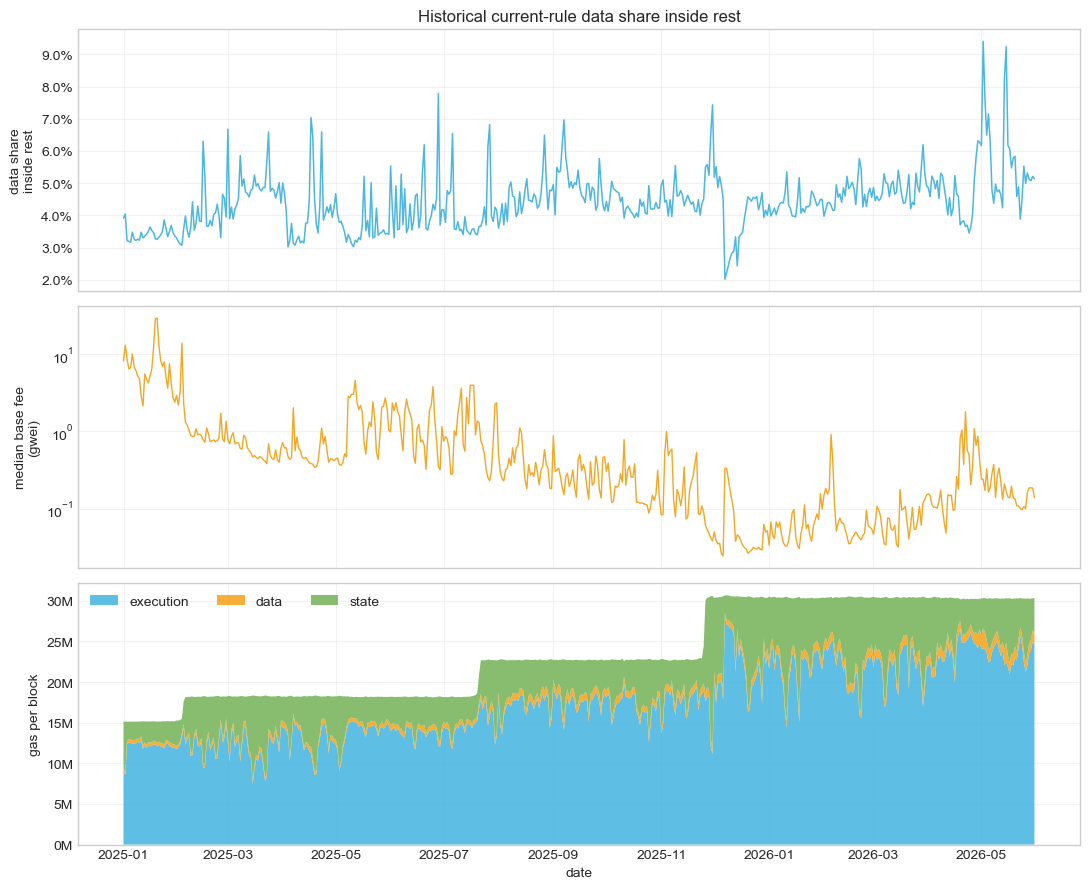

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(panel["date"], panel["data_share_rest_current"], linewidth=1.1, color="#4CB7E1")
axes[0].set_ylabel("data share\ninside rest")
axes[0].set_title("Historical current-rule data share inside rest")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _pos: f"{100*x:.1f}%"))

axes[1].plot(panel["date"], panel["median_base_fee_per_gas"] / GWEI, linewidth=1.0, color="#F5A623")
axes[1].set_ylabel("median base fee\n(gwei)")
axes[1].set_yscale("log")

axes[2].stackplot(
    panel["date"],
    panel["execution_gas_current_per_block"],
    panel["data_gas_current_per_block"],
    panel["state_gas_current_per_block"],
    labels=["execution", "data", "state"],
    colors=["#4CB7E1", "#F5A623", "#7BB661"],
    alpha=0.9,
)
axes[2].set_ylabel("gas per block")
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _pos: f"{x / 1e6:.0f}M"))
axes[2].legend(loc="upper left", ncol=3)

for ax in axes:
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("date")
plt.tight_layout()
plot_path = PLOTS_DIR / f"glamsterdam_equilibrium_historical_decomposition_{DATE_LABEL}.png"
fig.savefig(plot_path, dpi=160)
plot_path


In [4]:
def summarize_anchor(frame: pd.DataFrame, name: str) -> dict:
    blocks = float(frame["block_count"].sum())
    quantities = {
        "execution": float(frame["execution_gas_current"].sum() / blocks),
        "data": float(frame["data_gas_current"].sum() / blocks),
        "state": float(frame["state_gas_current"].sum() / blocks),
    }
    total = sum(quantities.values())
    base_fee_median = float(frame["median_base_fee_per_gas"].median())
    base_fee_gas_weighted = float(
        (frame["gas_weighted_base_fee_per_gas"] * frame["gas_used_current"]).sum()
        / frame["gas_used_current"].sum()
    )
    return {
        "anchor_name": "available_exact_current_data_panel",
        "start_date": frame["date"].min().date().isoformat(),
        "end_date": frame["date"].max().date().isoformat(),
        "days": len(frame),
        "blocks": blocks,
        "base_fee_ref_wei": base_fee_median,
        "base_fee_ref_gwei": base_fee_median / GWEI,
        "gas_weighted_base_fee_gwei": base_fee_gas_weighted / GWEI,
        "execution_gas_per_block": quantities["execution"],
        "data_gas_per_block": quantities["data"],
        "state_gas_per_block": quantities["state"],
        "total_gas_per_block": total,
        "execution_share": quantities["execution"] / total,
        "data_share": quantities["data"] / total,
        "state_share": quantities["state"] / total,
        "data_share_within_rest": quantities["data"] / (quantities["execution"] + quantities["data"]),
    }

anchor_table = pd.DataFrame([summarize_anchor(panel, "available_exact_current_data_panel")])
anchor_table.to_csv(OUT_ANCHOR_CSV, index=False)

# One model anchor. The time-series plot above is the resource-mix diagnostic.
ANCHOR_NAME = "available_exact_current_data_panel"


## Behavioral And Metering Parameters

The demand model has three behavioral inputs:

$$
\epsilon_{\text{agg}}
$$

governs total demand response to the common price index.

$$
\eta_{\text{state}}
$$

governs the state-vs-rest share response.

$$
\eta_{\text{data}}
$$

governs the data-vs-execution share response inside rest.

The metering parameters are separate:

$$
(m_{\text{execution}}, m_{\text{data}}, m_{\text{state}})
$$

They represent counterfactual Glamsterdam gas accounting, not elasticities. This
notebook sweeps them because the exact aggregate multiplier depends on transaction
composition.


In [5]:
# Central behavioral values from the reports/event studies, plus sensitivity.
# eta_data is intentionally tight: 0.12 is the broad gas-limit-event
# long-run central estimate; 0.268 is the cumulative gas-limit-event
# sensitivity; 0.43 is the direct EIP-7623 calldata-heavy sensitivity.
EPS_AGG_VALUES = [0.10, 0.175, 0.28]
ETA_STATE_VALUES = [0.17, 0.43, 0.97]
ETA_DATA_VALUES = [0.12, 0.268, 0.43]

# Glamsterdam target candidates. A 100M gas limit means a 50M EIP-1559 target.
GAS_LIMIT_VALUES = [60_000_000, 100_000_000, 150_000_000, 200_000_000]

# Repricing/metering sweeps. 5.8 and 1.9 are the 500-block literal accounting
# reference values; larger state multipliers match Maria-style design sweeps.
M_EXECUTION_VALUES = [1.0]
M_DATA_VALUES = [1.0, 1.5, 1.9, 2.5, 3.0]
M_STATE_VALUES = [5.8, 10.0, 15.0, 25.0, 30.0, 45.0]

CENTRAL = {
    "anchor_name": "available_exact_current_data_panel",
    "gas_limit": 100_000_000,
    "m_execution": 1.0,
    "m_data": 1.9,
    "m_state": 5.8,
    "eps_agg": 0.175,
    "eta_state": 0.43,
    "eta_data": 0.12,
}

pd.DataFrame({
    "parameter": [
        "epsilon_agg", "eta_state", "eta_data", "gas_limit",
        "m_execution", "m_data", "m_state",
    ],
    "sweep_values": [
        EPS_AGG_VALUES, ETA_STATE_VALUES, ETA_DATA_VALUES, GAS_LIMIT_VALUES,
        M_EXECUTION_VALUES, M_DATA_VALUES, M_STATE_VALUES,
    ],
})


,parameter,sweep_values
0,epsilon_agg,"[0.1, 0.175, 0.28]"
1,eta_state,"[0.17, 0.43, 0.97]"
2,eta_data,"[0.12, 0.268, 0.43]"
3,gas_limit,"[60000000, 100000000, 150000000, 200000000]"
4,m_execution,[1.0]
5,m_data,"[1.0, 1.5, 1.9, 2.5, 3.0]"
6,m_state,"[5.8, 10.0, 15.0, 25.0, 30.0, 45.0]"


## Solve Equilibrium

For each parameter tuple, the model solves for a single Glamsterdam base fee
$b^\*$ such that:

$$
\max\left(
  m_e q_e(b^*) + m_d q_d(b^*),
  m_s q_s(b^*)
\right)
= \frac{\text{gas limit}}{2}
$$

unless the fee floor binds. The base fee is a scalar because this is still the
Glamsterdam / EIP-8037 shared market, not full EIP-7999.


In [6]:
def make_anchor(row: pd.Series) -> Anchor:
    quantities = {
        "execution": float(row["execution_gas_per_block"]),
        "data": float(row["data_gas_per_block"]),
        "state": float(row["state_gas_per_block"]),
    }
    return Anchor(
        quantities=quantities,
        effective_prices={name: float(row["base_fee_ref_wei"]) for name in quantities},
    )


def solve_glamsterdam_equilibrium(
    *,
    anchor_name: str,
    gas_limit: float,
    m_execution: float,
    m_data: float,
    m_state: float,
    eps_agg: float,
    eta_state: float,
    eta_data: float,
    share_mode: str = "maria_own_price",
) -> dict:
    anchor_row = anchor_table.loc[anchor_table["anchor_name"] == anchor_name].iloc[0]
    anchor = make_anchor(anchor_row)
    params = DemandParams(
        eps_agg=eps_agg,
        eta_state=eta_state,
        eta_data=eta_data,
        share_mode=share_mode,
    )
    multipliers = {"execution": m_execution, "data": m_data, "state": m_state}
    world = WorldSpec(
        name="glamsterdam_shared_8037",
        multipliers=multipliers,
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=float(gas_limit) / 2.0,
            ),
        ),
    )
    eq = solve_equilibrium(anchor, params, world)

    regular_metered = (
        eq.quantities["execution"] * m_execution
        + eq.quantities["data"] * m_data
    )
    state_metered = eq.quantities["state"] * m_state
    binding_branch = "regular" if regular_metered >= state_metered else "state"

    epsilon_rest = implied_anchor_elasticities(
        anchor,
        DemandParams(eps_agg=eps_agg, eta_state=eta_state, eta_data=0.0, share_mode=share_mode),
    )["rest"]
    alpha_data_rest = anchor.data_share_of_rest
    epsilon_data_local = epsilon_rest + eta_data * (1.0 - alpha_data_rest)
    epsilon_execution_local = epsilon_rest - eta_data * alpha_data_rest

    return {
        "anchor_name": anchor_name,
        "gas_limit": gas_limit,
        "gas_target": gas_limit / 2.0,
        "m_execution": m_execution,
        "m_data": m_data,
        "m_state": m_state,
        "eps_agg": eps_agg,
        "eta_state": eta_state,
        "eta_data": eta_data,
        "epsilon_rest_at_anchor": epsilon_rest,
        "epsilon_data_local": epsilon_data_local,
        "epsilon_execution_local": epsilon_execution_local,
        "alpha_data_given_rest_anchor": alpha_data_rest,
        "base_fee_ref_gwei": float(anchor_row["base_fee_ref_gwei"]),
        "equilibrium_base_fee_wei": eq.prices_wei["regular_state"],
        "equilibrium_base_fee_gwei": eq.prices_wei["regular_state"] / GWEI,
        "base_fee_ratio_to_anchor": eq.prices_wei["regular_state"] / float(anchor_row["base_fee_ref_wei"]),
        "effective_price_ratio_execution": eq.effective_price_ratios["execution"],
        "effective_price_ratio_data": eq.effective_price_ratios["data"],
        "effective_price_ratio_state": eq.effective_price_ratios["state"],
        "quantity_execution": eq.quantities["execution"],
        "quantity_data": eq.quantities["data"],
        "quantity_state": eq.quantities["state"],
        "regular_metered_gas": regular_metered,
        "state_metered_gas": state_metered,
        "bottleneck_metered_gas": max(regular_metered, state_metered),
        "binding_branch": binding_branch,
        "target_gap_gas": max(regular_metered, state_metered) - gas_limit / 2.0,
        "demand_expansion": eq.demand_expansion,
        "alpha_state_equilibrium": eq.alpha_state,z
        "data_share_rest_equilibrium": eq.quantities["data"] / (eq.quantities["data"] + eq.quantities["execution"]),
        "floor_binding": eq.floor_binding["regular_state"],
        "target_unreachable": eq.target_unreachable["regular_state"],
        "converged": eq.converged,
        "sweeps": eq.sweeps,
    }

rows = []
for values in product(
    [ANCHOR_NAME],
    GAS_LIMIT_VALUES,
    M_EXECUTION_VALUES,
    M_DATA_VALUES,
    M_STATE_VALUES,
    EPS_AGG_VALUES,
    ETA_STATE_VALUES,
    ETA_DATA_VALUES,
):
    rows.append(solve_glamsterdam_equilibrium(
        anchor_name=values[0],
        gas_limit=values[1],
        m_execution=values[2],
        m_data=values[3],
        m_state=values[4],
        eps_agg=values[5],
        eta_state=values[6],
        eta_data=values[7],
    ))

results = pd.DataFrame(rows)
results.to_csv(OUT_RESULTS_CSV, index=False)

print(f"wrote {OUT_RESULTS_CSV}")
print(results.shape)
results.head()


wrote /Users/william/PycharmProjects/eip-7999-research/data/glamsterdam_aggregate_equilibrium_results_2025-01-01_2026-06-01.csv
(3240, 35)


,anchor_name,gas_limit,gas_target,m_execution,m_data,m_state,eps_agg,eta_state,eta_data,epsilon_rest_at_anchor,...,bottleneck_metered_gas,binding_branch,target_gap_gas,demand_expansion,alpha_state_equilibrium,data_share_rest_equilibrium,floor_binding,target_unreachable,converged,sweeps
0,available_exact_current_data_panel,60000000,"30,000,000.000000",1.000000,1.000000,5.800000,0.100000,0.170000,0.120000,0.060913,...,"30,000,000.000248",state,0.000248,1.038761,0.211401,0.044607,False,False,True,2
1,available_exact_current_data_panel,60000000,"30,000,000.000000",1.000000,1.000000,5.800000,0.100000,0.170000,0.268000,0.060913,...,"30,000,000.000248",state,0.000248,1.038761,0.211401,0.044607,False,False,True,2
2,available_exact_current_data_panel,60000000,"30,000,000.000000",1.000000,1.000000,5.800000,0.100000,0.170000,0.430000,0.060913,...,"30,000,000.000248",state,0.000248,1.038761,0.211401,0.044607,False,False,True,2
3,available_exact_current_data_panel,60000000,"30,000,000.000000",1.000000,1.000000,5.800000,0.100000,0.430000,0.120000,0.001132,...,"30,000,000.000435",state,0.000435,1.069996,0.205230,0.044607,False,False,True,2
4,available_exact_current_data_panel,60000000,"30,000,000.000000",1.000000,1.000000,5.800000,0.100000,0.430000,0.268000,0.001132,...,"30,000,000.000435",state,0.000435,1.069996,0.205230,0.044607,False,False,True,2


## Central Scenario

The central row below uses:

$$
\epsilon_{\text{agg}} = 0.175,
\qquad
\eta_{\text{state}} = 0.43,
\qquad
\eta_{\text{data}} = 0.12
$$

where $\eta_{\text{data}}=0.12$ is the broad gas-limit-event long-run central value. The sweep keeps $0.268$ as the cumulative gas-limit-event sensitivity and $0.43$ as the direct EIP-7623 calldata-heavy sensitivity.

The central row also uses a 100M gas limit and pilot-literal accounting multipliers:

$$
m_{\text{execution}}=1.0,
\quad
m_{\text{data}}=1.9,
\quad
m_{\text{state}}=5.8.
$$

This is not the final answer; it is a readable reference point inside the wider
sweep.


In [7]:
def select_rows(frame: pd.DataFrame, **kwargs) -> pd.DataFrame:
    mask = pd.Series(True, index=frame.index)
    for key, value in kwargs.items():
        if isinstance(value, float):
            mask &= np.isclose(frame[key].astype(float), value)
        else:
            mask &= frame[key].eq(value)
    return frame[mask].copy()

central = select_rows(results, **CENTRAL)
central[[
    "anchor_name", "gas_limit", "gas_target", "m_data", "m_state",
    "eps_agg", "eta_state", "eta_data",
    "base_fee_ref_gwei", "equilibrium_base_fee_gwei", "base_fee_ratio_to_anchor",
    "effective_price_ratio_execution", "effective_price_ratio_data", "effective_price_ratio_state",
    "regular_metered_gas", "state_metered_gas", "binding_branch",
    "demand_expansion", "alpha_state_equilibrium", "data_share_rest_equilibrium",
]]


,anchor_name,gas_limit,gas_target,m_data,m_state,eps_agg,eta_state,eta_data,base_fee_ref_gwei,equilibrium_base_fee_gwei,base_fee_ratio_to_anchor,effective_price_ratio_execution,effective_price_ratio_data,effective_price_ratio_state,regular_metered_gas,state_metered_gas,binding_branch,demand_expansion,alpha_state_equilibrium,data_share_rest_equilibrium
1146,available_exact_current_data_panel,100000000,"50,000,000.000000",1.900000,5.800000,0.175000,0.430000,0.120000,0.333215,0.032026,0.096113,0.096113,0.182615,0.557456,"23,294,954.685453","50,000,000.000848",state,1.319424,0.277388,0.041438


## Gas-Limit Curve

This curve keeps the behavioral parameters and data multiplier fixed, then sweeps
Glamsterdam gas limits and state multipliers.

The point is to see whether the equilibrium price is mostly controlled by the
state branch or by the regular branch as capacity increases.


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_equilibrium_base_fee_by_limit_2025-01-01_2026-06-01.png')

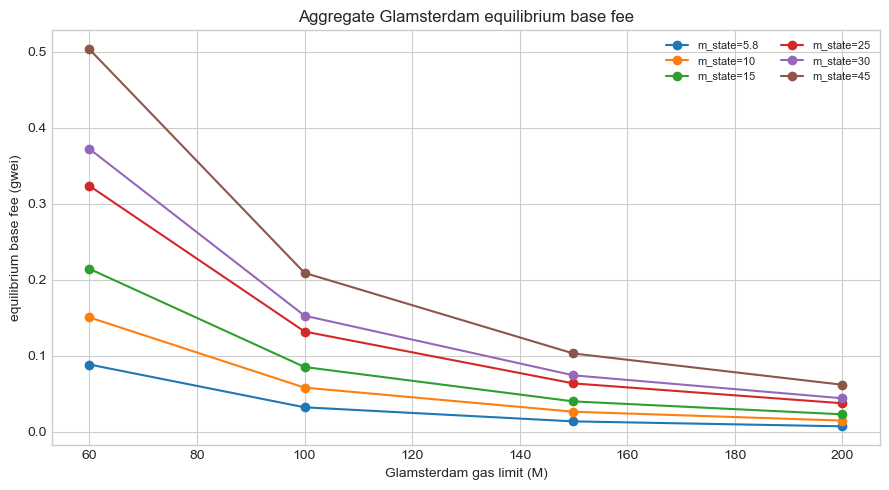

In [8]:
curve = select_rows(
    results,
    anchor_name=CENTRAL["anchor_name"],
    m_execution=CENTRAL["m_execution"],
    m_data=CENTRAL["m_data"],
    eps_agg=CENTRAL["eps_agg"],
    eta_state=CENTRAL["eta_state"],
    eta_data=CENTRAL["eta_data"],
)

fig, ax = plt.subplots(figsize=(9, 5))
for m_state, grp in curve.groupby("m_state"):
    grp = grp.sort_values("gas_limit")
    ax.plot(
        grp["gas_limit"] / 1e6,
        grp["equilibrium_base_fee_gwei"],
        marker="o",
        linewidth=1.5,
        label=f"m_state={m_state:g}",
    )
ax.set_xlabel("Glamsterdam gas limit (M)")
ax.set_ylabel("equilibrium base fee (gwei)")
ax.set_title("Aggregate Glamsterdam equilibrium base fee")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plot_path = PLOTS_DIR / f"glamsterdam_equilibrium_base_fee_by_limit_{DATE_LABEL}.png"
fig.savefig(plot_path, dpi=160)
plot_path


## Repricing Heatmap At 100M Gas Limit

This heatmap fixes the central behavioral parameters and varies the two uncertain
metering multipliers:

- rows: $m_{\text{state}}$;
- columns: $m_{\text{data}}$.

The text in each cell shows which branch binds: `S` for state, `R` for regular.


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_equilibrium_repricing_heatmap_100M_2025-01-01_2026-06-01.png')

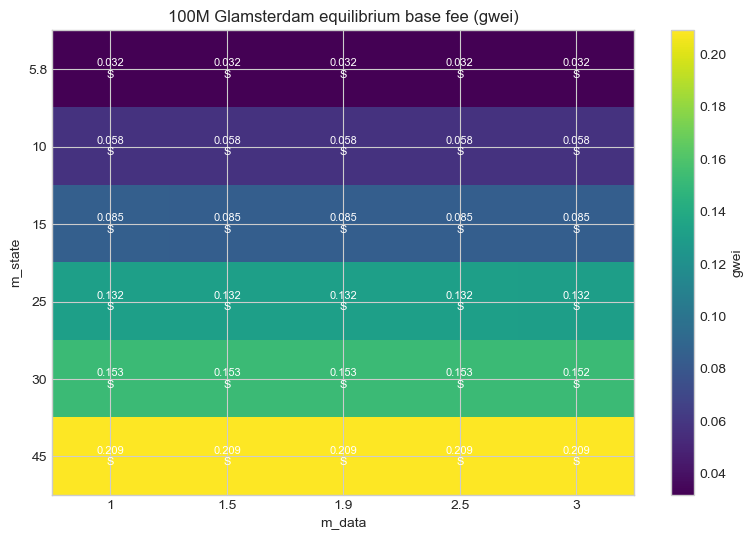

In [9]:
heat = select_rows(
    results,
    anchor_name=CENTRAL["anchor_name"],
    gas_limit=CENTRAL["gas_limit"],
    m_execution=CENTRAL["m_execution"],
    eps_agg=CENTRAL["eps_agg"],
    eta_state=CENTRAL["eta_state"],
    eta_data=CENTRAL["eta_data"],
)

pivot = heat.pivot(index="m_state", columns="m_data", values="equilibrium_base_fee_gwei").sort_index(ascending=True)
bind = heat.pivot(index="m_state", columns="m_data", values="binding_branch").reindex(index=pivot.index, columns=pivot.columns)

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(pivot.columns)), [f"{x:g}" for x in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [f"{x:g}" for x in pivot.index])
ax.set_xlabel("m_data")
ax.set_ylabel("m_state")
ax.set_title("100M Glamsterdam equilibrium base fee (gwei)")
for i, m_state in enumerate(pivot.index):
    for j, m_data in enumerate(pivot.columns):
        label = "S" if bind.loc[m_state, m_data] == "state" else "R"
        ax.text(j, i, f"{pivot.loc[m_state, m_data]:.3f}\n{label}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, label="gwei")
plt.tight_layout()
plot_path = PLOTS_DIR / f"glamsterdam_equilibrium_repricing_heatmap_100M_{DATE_LABEL}.png"
fig.savefig(plot_path, dpi=160)
plot_path


## Sensitivity Summary

For each gas limit, this table reports the distribution of equilibrium base fees
across the full parameter sweep. This is the safer headline than any single
scenario.


In [10]:
sensitivity = (
    results[results["anchor_name"].eq(CENTRAL["anchor_name"])]
    .groupby("gas_limit")
    .agg(
        rows=("equilibrium_base_fee_gwei", "size"),
        base_fee_gwei_p10=("equilibrium_base_fee_gwei", lambda s: s.quantile(0.10)),
        base_fee_gwei_p50=("equilibrium_base_fee_gwei", "median"),
        base_fee_gwei_p90=("equilibrium_base_fee_gwei", lambda s: s.quantile(0.90)),
        state_binding_share=("binding_branch", lambda s: (s == "state").mean()),
        median_effective_state_price=("effective_price_ratio_state", "median"),
        median_effective_data_price=("effective_price_ratio_data", "median"),
        median_demand_expansion=("demand_expansion", "median"),
    )
    .reset_index()
)
sensitivity["gas_limit_M"] = sensitivity["gas_limit"] / 1e6
sensitivity[[
    "gas_limit_M", "rows", "base_fee_gwei_p10", "base_fee_gwei_p50", "base_fee_gwei_p90",
    "state_binding_share", "median_effective_state_price", "median_effective_data_price",
    "median_demand_expansion",
]]


,gas_limit_M,rows,base_fee_gwei_p10,base_fee_gwei_p50,base_fee_gwei_p90,state_binding_share,median_effective_state_price,median_effective_data_price,median_demand_expansion
0,60.000000,810,0.072058,0.170577,3.205742,1.000000,9.278341,0.969111,0.850639
1,100.000000,810,0.036607,0.070858,0.804646,1.000000,3.962340,0.405017,0.990141
2,150.000000,810,0.013528,0.033353,0.279432,1.000000,2.423805,0.226791,1.072046
3,200.000000,810,0.006979,0.023259,0.089153,1.000000,1.534011,0.140225,1.162953


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_equilibrium_sensitivity_band_2025-01-01_2026-06-01.png')

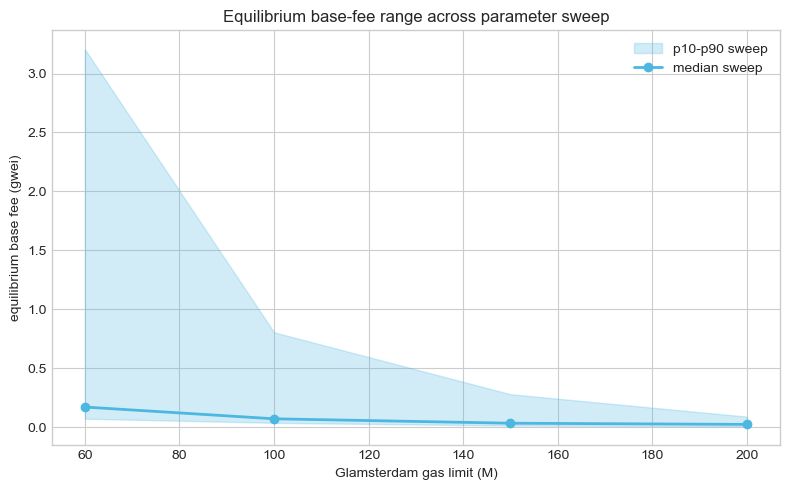

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
x = sensitivity["gas_limit"] / 1e6
ax.fill_between(x, sensitivity["base_fee_gwei_p10"], sensitivity["base_fee_gwei_p90"], color="#4CB7E1", alpha=0.25, label="p10-p90 sweep")
ax.plot(x, sensitivity["base_fee_gwei_p50"], color="#4CB7E1", linewidth=2, marker="o", label="median sweep")
ax.set_xlabel("Glamsterdam gas limit (M)")
ax.set_ylabel("equilibrium base fee (gwei)")
ax.set_title("Equilibrium base-fee range across parameter sweep")
ax.legend()
plt.tight_layout()
plot_path = PLOTS_DIR / f"glamsterdam_equilibrium_sensitivity_band_{DATE_LABEL}.png"
fig.savefig(plot_path, dpi=160)
plot_path


## What To Read From This Notebook

This notebook is intentionally not a passive replay. It does not preserve the
500 historical block shapes. It asks a cleaner aggregate question:

> Given historical resource shares and assumed Glamsterdam repricing multipliers,
> what shared base fee clears the EIP-8037 bottleneck target?

The important interpretation points are:

- $m_{\text{state}}$ and $m_{\text{data}}$ are accounting/repricing assumptions,
  not demand elasticities.
- $\epsilon_{\text{agg}}$, $\eta_{\text{state}}$, and $\eta_{\text{data}}$ are
  behavioral assumptions.
- A state-binding result means the state branch of
  $\max(\text{regular}, \text{state})$ is the branch that reaches the target at
  the solved base fee.
- A regular-binding result means execution plus data reaches the target first.

For a full EIP-7999 model, this same aggregate anchor can be reused, but the
world spec should have separate fee dimensions for execution, data/bandwidth,
and state.
